In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.datasets import make_classification, make_regression
from sklearn.metrics import mean_squared_error, accuracy_score


In [3]:
# # Create data for linear regression (predicting real values)
# X_reg, y_reg = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)

# # Create data for logistic regression (predicting classes)
# X_clf, y_clf = make_classification(n_samples=100, n_features=1,
#                                    n_informative=1, n_redundant=0,
#                                    n_clusters_per_class=1, random_state=42)

# Load the KC Housing dataset
df = pd.read_csv('KC_housing_data.csv')

# Drop irrelevant columns
df = df.drop(columns=['id', 'date'], errors='ignore')
df = df.dropna()  # remove any rows with missing values

# ✅ Linear Regression: predict continuous house price
X_reg = df[['sqft_living']].values   # single feature (like original n_features=1)
y_reg = df['price'].values

# ✅ Logistic Regression: classify expensive (1) vs not expensive (0)
X_clf = df[['sqft_living']].values
y_clf = (df['price'] > df['price'].median()).astype(int).values


In [4]:
# Linear Regression model
lin_model = LinearRegression()
lin_model.fit(X_reg, y_reg)
lin_pred = lin_model.predict(X_reg)


In [5]:
# Logistic Regression model
log_model = LogisticRegression()
log_model.fit(X_clf, y_clf)
log_pred = log_model.predict(X_clf)

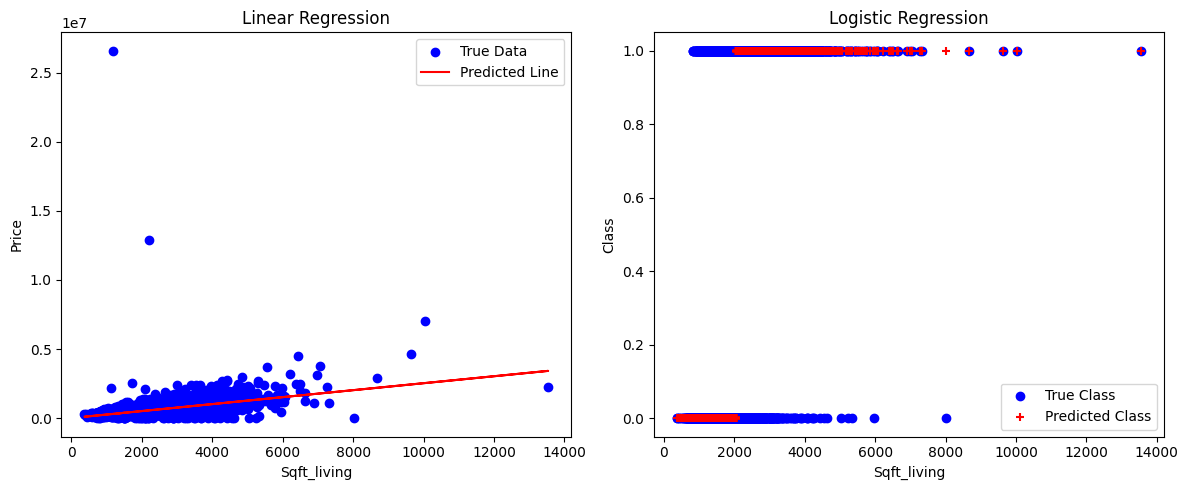

In [6]:
# Plot results for Linear Regression
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X_reg, y_reg, color='blue', label='True Data')
plt.plot(X_reg, lin_pred, color='red', label='Predicted Line')
plt.title('Linear Regression')
plt.xlabel('Sqft_living')
plt.ylabel('Price')
plt.legend()

# Plot results for Logistic Regression
plt.subplot(1,2,2)
plt.scatter(X_clf, y_clf, color='blue', label='True Class')
plt.scatter(X_clf, log_pred, color='red', marker='+', label='Predicted Class')
plt.title('Logistic Regression')
plt.xlabel('Sqft_living')
plt.ylabel('Class')
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
# Print metrics for comparison
print("Linear Regression mean squared error:", mean_squared_error(y_reg, lin_pred))
print("Logistic Regression accuracy:", accuracy_score(y_clf, log_pred))

Linear Regression mean squared error: 258959628843.36646
Logistic Regression accuracy: 0.7302173913043478


## Reflection: Linear vs Logistic Regression on KC Housing Data

**Linear Regression** was used to predict the actual house price — a continuous value.
The model learned a relationship between features like `sqft_living` and the price in dollars.
The MSE tells us how far off our predictions were on average (in squared dollars).
A lower MSE means more accurate price predictions.

**Logistic Regression** was used to classify houses as "expensive" (above median price) or "not expensive".
Instead of predicting an exact value, it outputs a probability (0 to 1) and assigns a class label.
Accuracy tells us what percentage of houses were correctly classified.

**Key Difference:**
- Use **Linear Regression** when you need an exact number (e.g., "This house costs $450,000")
- Use **Logistic Regression** when you need a category (e.g., "Is this house expensive? Yes/No")

On the KC housing dataset, logistic regression achieved high accuracy because the median
clearly separates the data into two distinct groups. Linear regression, however, is more
informative for real-world pricing applications where the exact value matters.
